# Perturbation experiments with EHRformer

In [1]:
import sys
sys.path.insert(0, '../lib')

In [ ]:
import numpy as np
import torch
import pandas as pd
import pickle
from datasets import Dataset
from transformers import BertForMaskedLM, BertConfig, BertForSequenceClassification
import umap
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import typing
import transformers
import transformers.modeling_outputs

import common_data
import common_plots

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
common_plots.setup_plotting()

In [4]:
%config InlineBackend.figure_format = "retina"

In [ ]:
# TORCH MISC
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 16

# DATA MISC
NB_OF_BINS = 4 + 1 # Number of bins into which data values were binned (4) + 1 for NA

IS_NA_BIN_NAME = 'binis_na' # Name of the column for NA bin, this changed because of quartile binning

# PATH MISC
EHR_FILE_PATH = common_data.EHRFORMER_BINS # PATH TO PICKLED BINNED DATA DF

# TOKEN_MISC
CLS_TOKEN = 0
MASK_TOKEN = 1

In [6]:
pd.options.display.max_columns = 300

## 1. Prepare Dataset and Tokens

In [7]:
with open(EHR_FILE_PATH, 'rb') as pickle_handle:
    ehr_df = pickle.load(pickle_handle)

In [8]:
ehr_df.shape

(15287, 250)

## 1.1 Checks

Which features don't have 5 bins?

In [9]:
ehr_df.columns.to_frame().groupby(0).size().ne(5).replace({False: np.nan}).dropna()

Series([], dtype: float64)

Ok, good, moving forward

How many features? and which

In [10]:
ehr_df.columns.to_frame()[0].nunique()

50

In [11]:
COLUMNS = ehr_df.columns.to_frame()[0].unique().tolist()

## 1.2 Prepare dataset

Define vocab

In [12]:
# Define vocab
VOCAB = {
    "CLS": CLS_TOKEN,
    "MASK": MASK_TOKEN,
    **{
        f'bin{ind_}': ind_ + 2 for ind_ in range(NB_OF_BINS - 1)
    },
    IS_NA_BIN_NAME: NB_OF_BINS + 2 - 1
}

In [ ]:
labels_df = pd.read_csv(common_data.CLINICAL_LABELS)

In [14]:
ehr_bins = [
    [
        column_name[1]
        for column_name, column_value in zip(ehr_df.columns, row_)
        if column_value
    ]
    for row_nb, row_ in ehr_df.iterrows()
]

In [15]:
ehr_row_tokens_all = [
    [VOCAB[token] for token in ehr_row]
    for ehr_row in ehr_bins
]

ehr_row_dataset_all = Dataset.from_dict({'input_ids': ehr_row_tokens_all})

## 1.3 Data Collator

In [ ]:
# Copy from ehrformer_finetunning_script.py
# But we remove labels
class EHRSequenceClassificationFormerDataCollator:
    def __init__(
        self,
        cls_token=CLS_TOKEN,
        mask_token=MASK_TOKEN,
    ):
        self.cls_token = cls_token
        self.mask_token = mask_token

    def __call__(self, ehrs):
        tokens = torch.tensor([
            [self.cls_token] + ehr_row['input_ids']
            for ehr_row in ehrs
        ])
        return {
            'input_ids': tokens
        }

## 2. Load the Pretrained Model

We're using the model pretrained on all data

In [ ]:
ehr_former: transformers.BertForMaskedLM = BertForMaskedLM.from_pretrained(
    '../data/01_ehrformer/models/pretrained/global/',
    output_hidden_states = True
) # type: ignore

In [18]:
data_collator = EHRSequenceClassificationFormerDataCollator()

input_tensor = data_collator(ehr_row_dataset_all)

## 3. Assess pretrained model on classification accuracy for tokens

We pass forward patient-days without any masking, and see how accurately it classifies the tokens

In [19]:
with torch.no_grad():
    outputs = ehr_former(input_tensor['input_ids'])

In [20]:
outputs.logits.argmax(-1)[:, 1:].shape

torch.Size([15287, 50])

Text(0.5, 0, 'Proportion of tokens correctly classified per day')

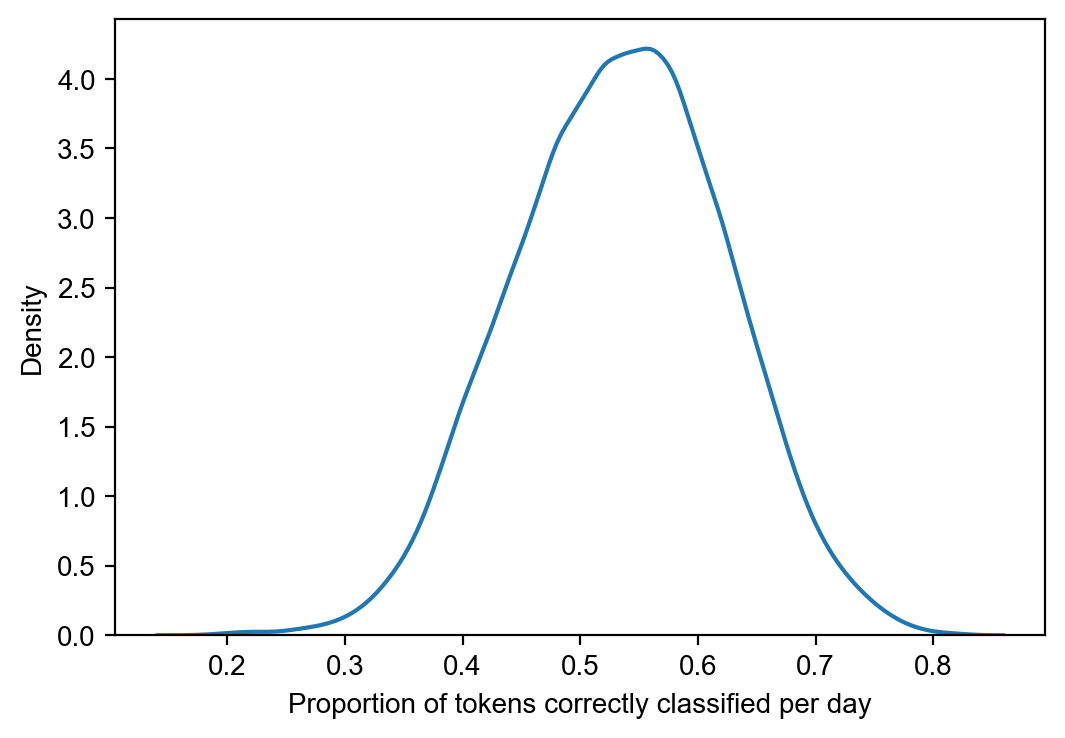

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.kdeplot(np.equal(
    input_tensor['input_ids'][:, 1:],
    outputs.logits.argmax(-1)[:, 1:]
).numpy().mean(axis=-1))
ax.set_xlabel('Proportion of tokens correctly classified per day')

In [22]:
for k, i in VOCAB.items():
    n_tokens = (input_tensor['input_ids'][:, 1:] == i).sum()
    n_predicted = (outputs.logits.argmax(-1)[:, 1:] == i).sum()
    print(f'Number of input and predicted tokens {k}: {n_tokens} | {n_predicted}')

Number of input and predicted tokens CLS: 0 | 2843
Number of input and predicted tokens MASK: 0 | 1
Number of input and predicted tokens bin0: 237989 | 306421
Number of input and predicted tokens bin1: 130959 | 91023
Number of input and predicted tokens bin2: 135115 | 156457
Number of input and predicted tokens bin3: 153689 | 207389
Number of input and predicted tokens binis_na: 106598 | 216


## 4. Perturbations

Plan is:
1. For a given variable and direction of perturbation
2. Select all days where this variable is not NA and not at the last quartile
3. For each of the remaining 3 bins
4. Set the variable to the extreme bin
5. Run forward pass
6. Get predicted bin
7. Drop CLS, MASK, NA
8. Compute bin difference to unperturbed predictions for the same day

In [23]:
def get_perturbation_effect(
    ehr_df: pd.DataFrame,
    feature: str,
    direction: typing.Literal['increase', 'decrease'],
    model: transformers.BertForMaskedLM,
    collator: typing.Callable[[Dataset], dict],
    unperturbed_predictions: transformers.modeling_outputs.MaskedLMOutput,
    token_vocab: dict[str, int]
) -> pd.DataFrame:
    BINS = ['bin0', 'bin1', 'bin2', 'bin3']
    BIN_TOKENS = [token_vocab[bin] for bin in BINS]

    if direction == 'increase':
        EXTREME_BIN = BINS[-1]
    else:
        EXTREME_BIN = BINS[0]

    result = []
    for bin in BINS:
        if bin == EXTREME_BIN:
            continue
        idx = ehr_df[(feature, bin)].eq(1)
        perturbed_bins = [
            [
                column_name[0] == feature and EXTREME_BIN or column_name[1]
                for column_name, column_value in zip(ehr_df.columns, row)
                if column_value
            ]
            for _, row in ehr_df.loc[idx].iterrows()
        ]
        perturbed_tokens = [
            [VOCAB[token] for token in ehr_row]
            for ehr_row in perturbed_bins
        ]
        perturbed_dataset = Dataset.from_dict({'input_ids': perturbed_tokens})
        perturbed_input_tensor = collator(perturbed_dataset)
        with torch.no_grad():
            perturbed_outputs = model(perturbed_input_tensor['input_ids'])
        unperturbed_preds = unperturbed_predictions.logits[idx.values].argmax(-1)[:, 1:].numpy()
        perturbed_preds = perturbed_outputs.logits.argmax(-1)[:, 1:].numpy()
        idx1 = np.isin(unperturbed_preds, BIN_TOKENS)
        idx2 = np.isin(perturbed_preds, BIN_TOKENS)
        mask = (idx1 & idx2)
        for i, var in enumerate(COLUMNS):
            if var == feature:
                continue
            unperturbed_bins = unperturbed_preds[:, i][mask[:, i]]
            perturbed_bins = perturbed_preds[:, i][mask[:, i]]
            bin_diff = np.abs(BINS.index(EXTREME_BIN) - BINS.index(bin))
            # positive difference means increase in bin value, cuz higher bin token means higher bin
            diff = (perturbed_bins - unperturbed_bins) / bin_diff
            result.append(dict(
                perturbation=feature,
                direction=direction,
                from_bin=bin,
                to_bin=EXTREME_BIN,
                variable=var,
                mean_diff=diff.mean(),
                std_diff=diff.std(),
            ))
    return pd.DataFrame(result)

In [24]:
PRETTY_NAMES = {
    'Plateau_Pressure': 'Plateau pressure',
    'Lung_Compliance': 'Lung compliance',
    'Minute_Ventilation': 'Minute ventilation',
    'PaO2FIO2_ratio': r'P$_{\mathrm{a}}$O$_2$/F$_{\mathrm{i}}$O$_2$',
    'days_on_ventilator': 'Days on ventilator',
    'day_of_hospitalization': 'Day of hospitalization',
    'week_of_hospitalization': 'Week of hospitalization',
    'mean_nat_score_until_yesterday': 'Mean NAT score until yesterday',
    'Gender': 'Sex',
    'ICU_stay': 'ICU stay number',
    'GCS_eye_opening': 'GCS eye opening score',
    'GCS_motor_response': 'GCS motor response score',
    'GCS_verbal_response': 'GCS verbal response score',
    'FiO2': r'F$_{\mathrm{i}}$O$_2$',
    'ABG_PaO2': r'P$_{\mathrm{a}}$O$_2$',
    'ABG_pH': 'pH',
    'D_dimer_ff': 'D-dimer',
    'days_of_icu_abx_until_today': 'ICU antibiotic days to date',
    'ABG_PaCO2': r'P$_{\mathrm{a}}$CO$_2$'
}
for col in COLUMNS:
    if col not in PRETTY_NAMES:
        PRETTY_NAMES[col] = col.replace('_', ' ').replace(' flag', '')

In [32]:
def plot_perturbation_effects(
    result_df: pd.DataFrame,
    name_map: dict[str, str] = None,
):
    BIN_NAMES = {
        'bin0': '1$^{\mathrm{st}}$',
        'bin1': '2$^{\mathrm{nd}}$',
        'bin2': '3$^{\mathrm{rd}}$',
        'bin3': '4$^{\mathrm{th}}$',
    }
    fig, ax = plt.subplots(figsize=(8, 10), constrained_layout=True)
    result_df = result_df.copy()
    result_df['variable'] = result_df['variable'].map(name_map)
    sns.boxplot(
        data=result_df,
        x='mean_diff',
        y='variable',
        color='lightgray',
        ax=ax,
        zorder=3,
    )
    sns.swarmplot(
        data=result_df,
        x='mean_diff',
        y='variable',
        hue='from_bin',
        ax=ax,
        zorder=4,
        palette=['C0', 'k', 'C3'],
        s=5
    )
    ax.grid(axis='both', zorder=1)
    ax.axvline(0, color='k', linestyle='--', zorder=2, lw=1)
    ax.set_xlabel('Average quartile change')
    ax.set_ylabel('')
    feature = name_map.get(result_df['perturbation'].iloc[0], result_df['perturbation'].iloc[0])
    direction = result_df['direction'].iloc[0]
    name = 'lowest' if direction == 'decrease' else 'highest'
    ax.set_title(f'Effect of changing {feature} to the {name} quartile')
    h, l = ax.get_legend_handles_labels()
    ax.legend(
        handles=h,
        labels=[BIN_NAMES[label] for label in l],
        title='From quartile',
        bbox_to_anchor=(1.01, 1),
        loc='upper left'
    )
    return fig

In [33]:
result_df = get_perturbation_effect(
    ehr_df,
    feature='Systolic_blood_pressure',
    direction='decrease',
    model=ehr_former,
    collator=data_collator,
    unperturbed_predictions=outputs,
    token_vocab=VOCAB
)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 66.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


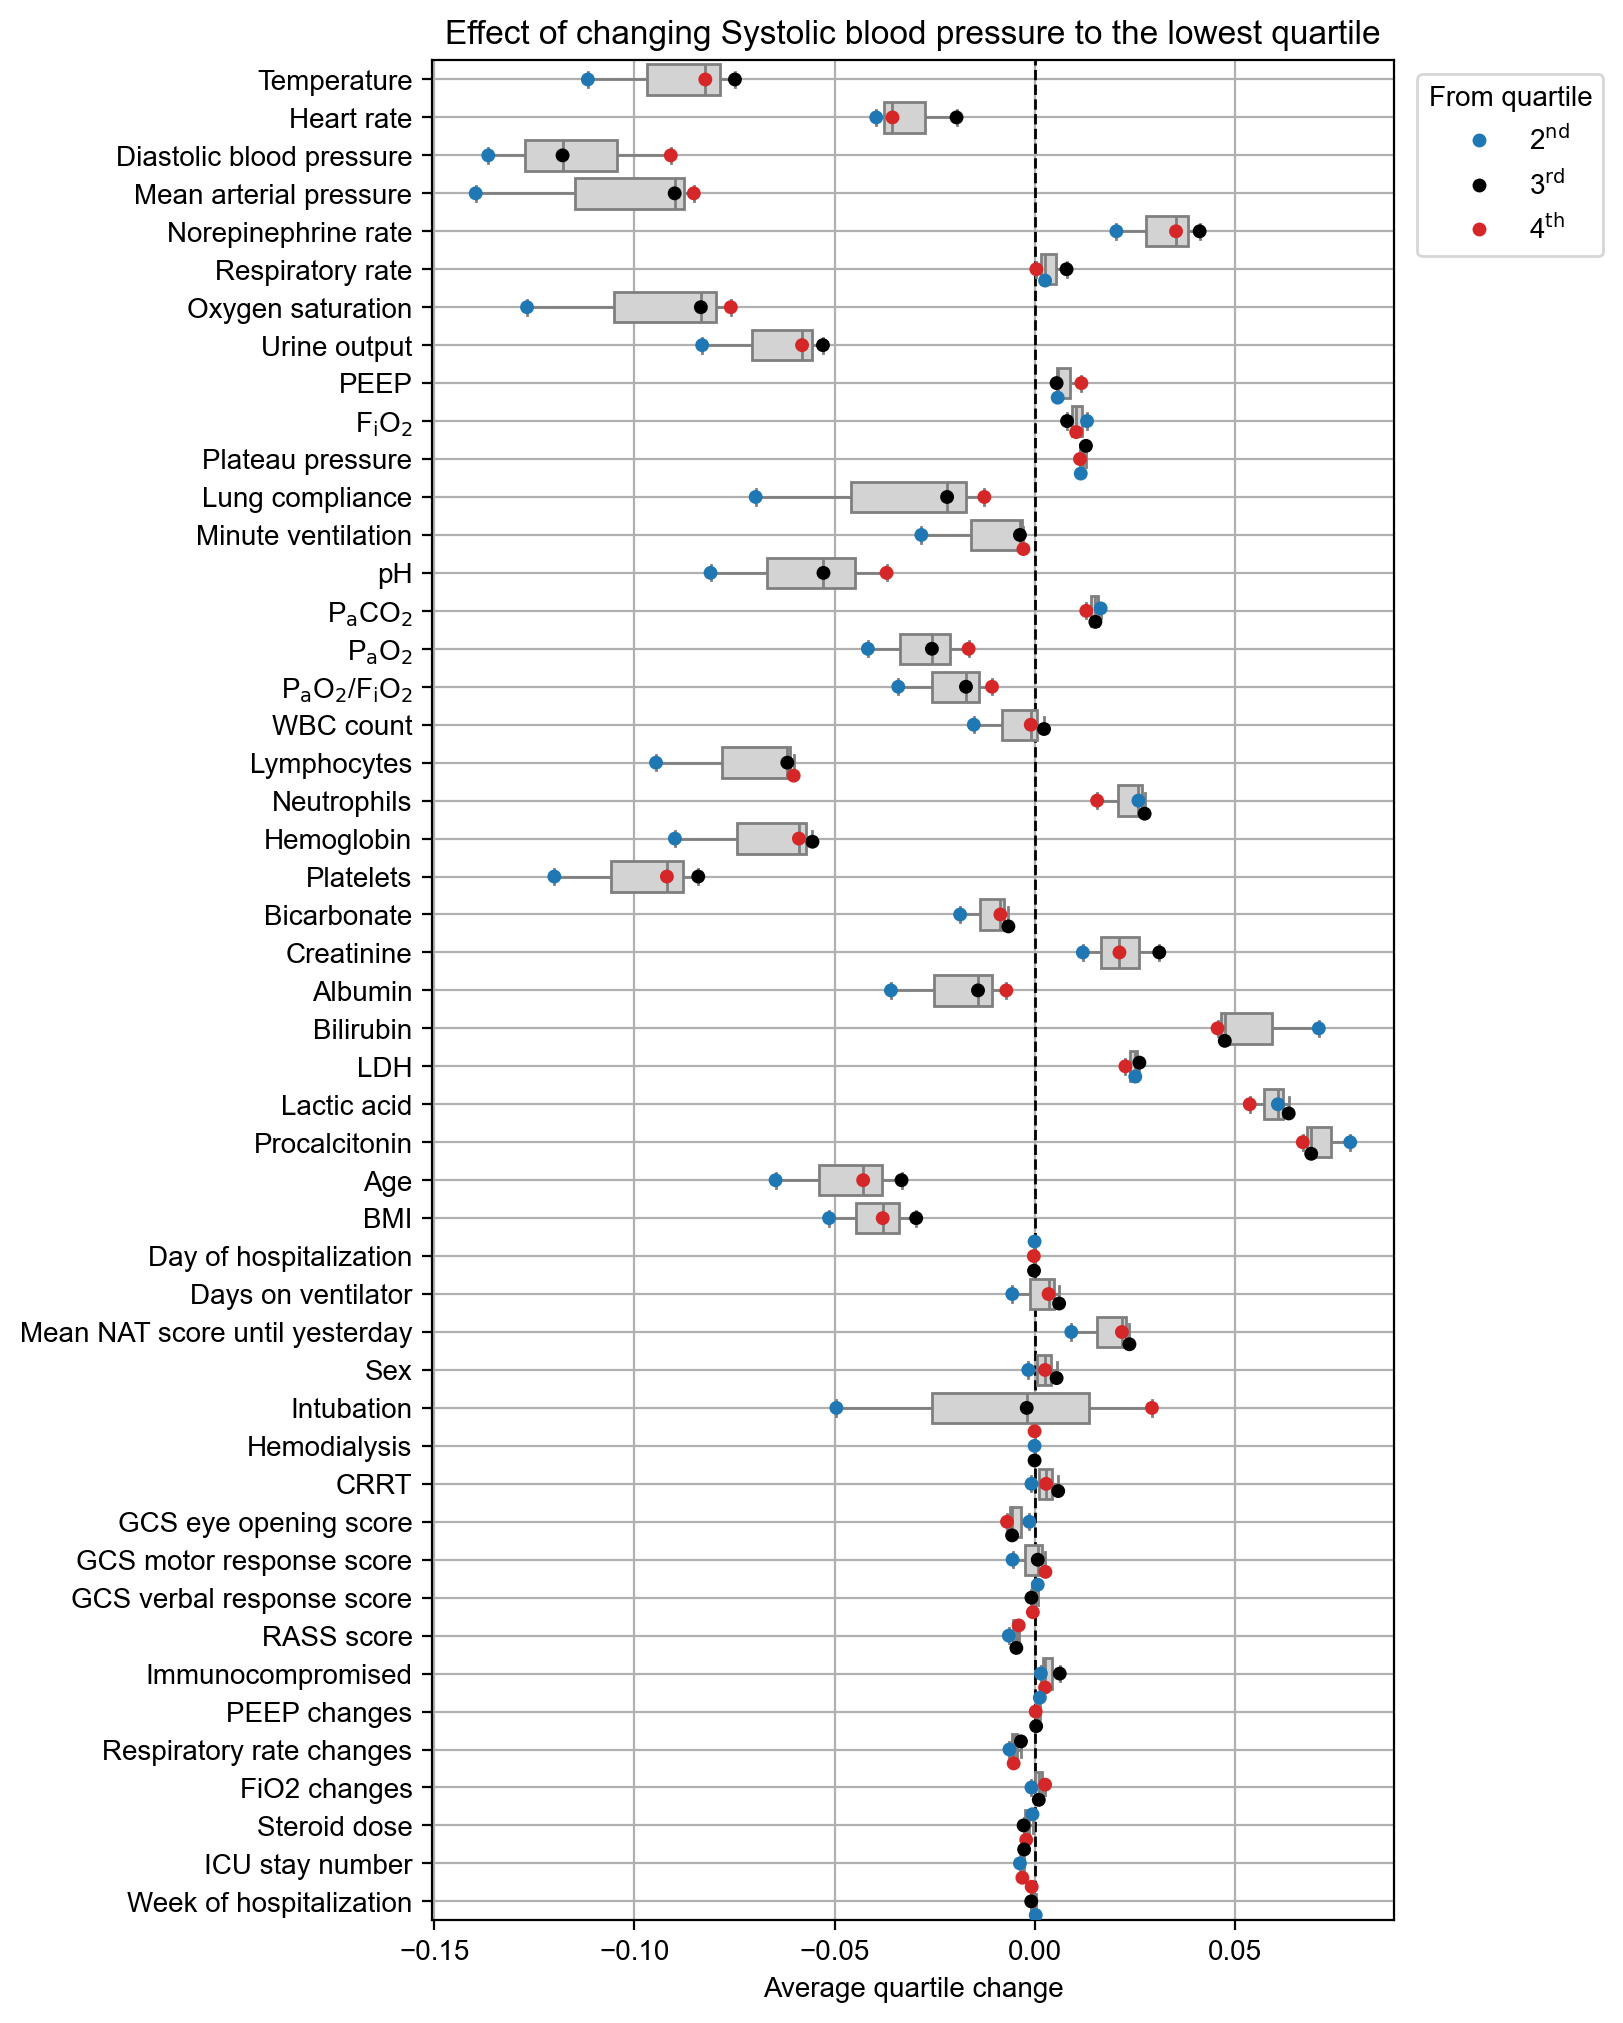

In [34]:
fig = plot_perturbation_effects(result_df, PRETTY_NAMES);
fig.savefig('00_plots/Fig_1i_perturb_sbp.pdf')

In [35]:
result_df = get_perturbation_effect(
    ehr_df,
    feature='PEEP',
    direction='increase',
    model=ehr_former,
    collator=data_collator,
    unperturbed_predictions=outputs,
    token_vocab=VOCAB
)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 66.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


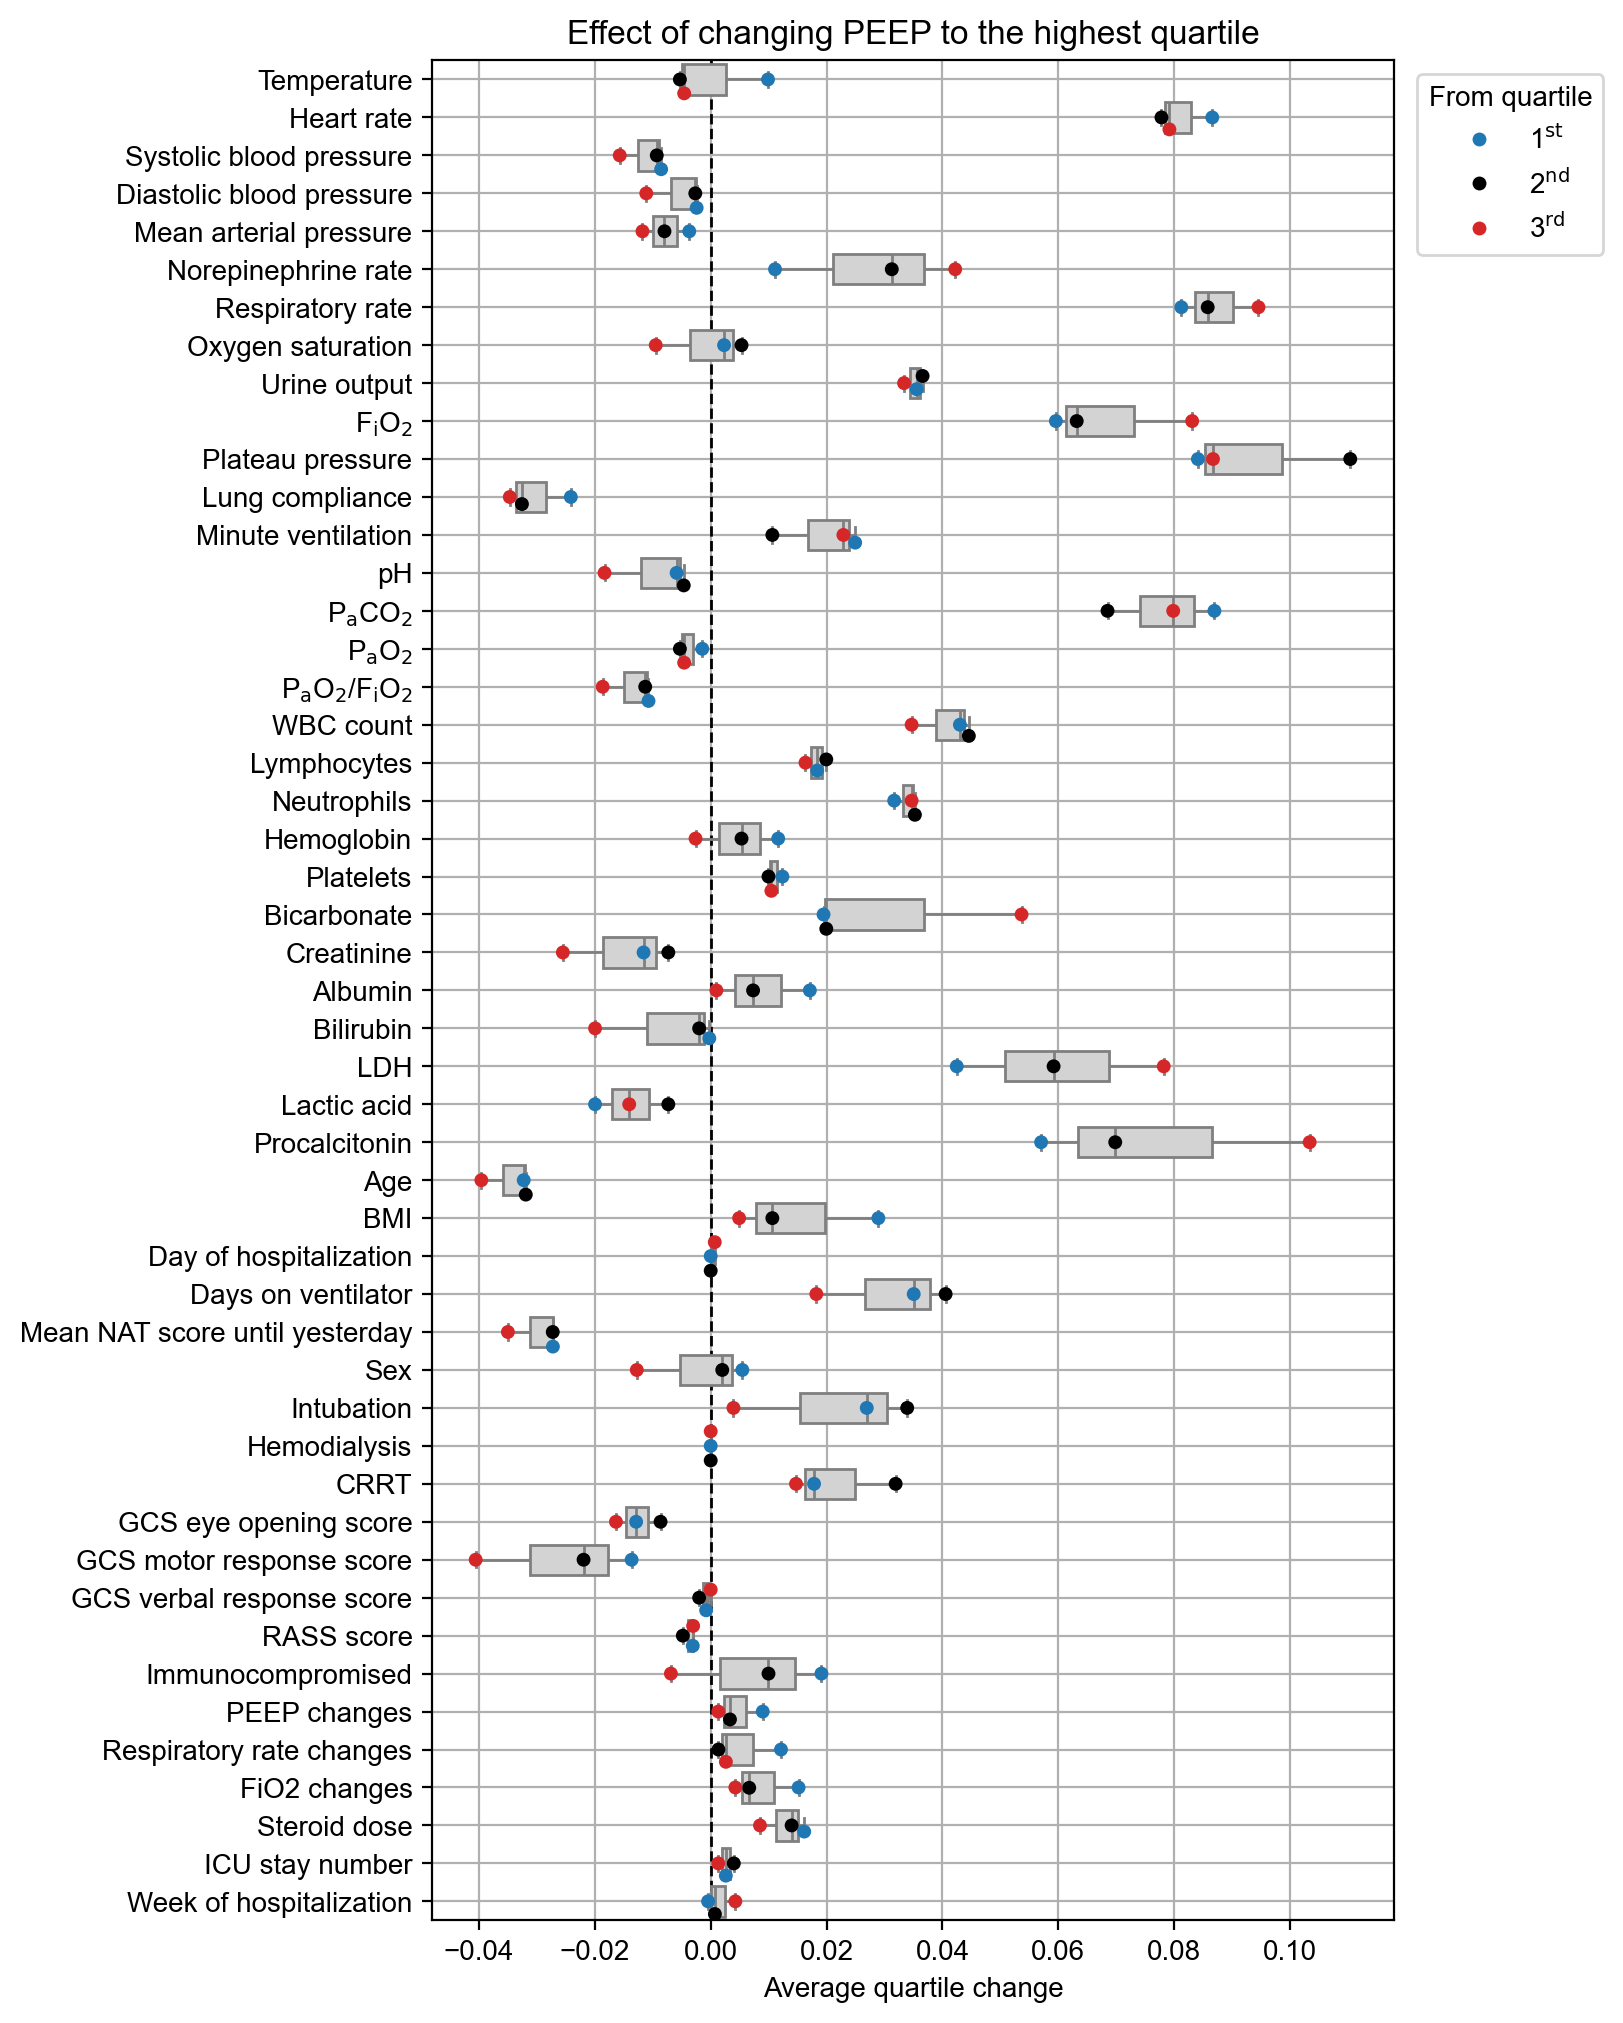

In [36]:
fig = plot_perturbation_effects(result_df, PRETTY_NAMES);
fig.savefig('00_plots/Fig_S3d_perturb_peep.pdf')

In [37]:
result_df = get_perturbation_effect(
    ehr_df,
    feature='Steroid_dose',
    direction='increase',
    model=ehr_former,
    collator=data_collator,
    unperturbed_predictions=outputs,
    token_vocab=VOCAB
)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 66.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


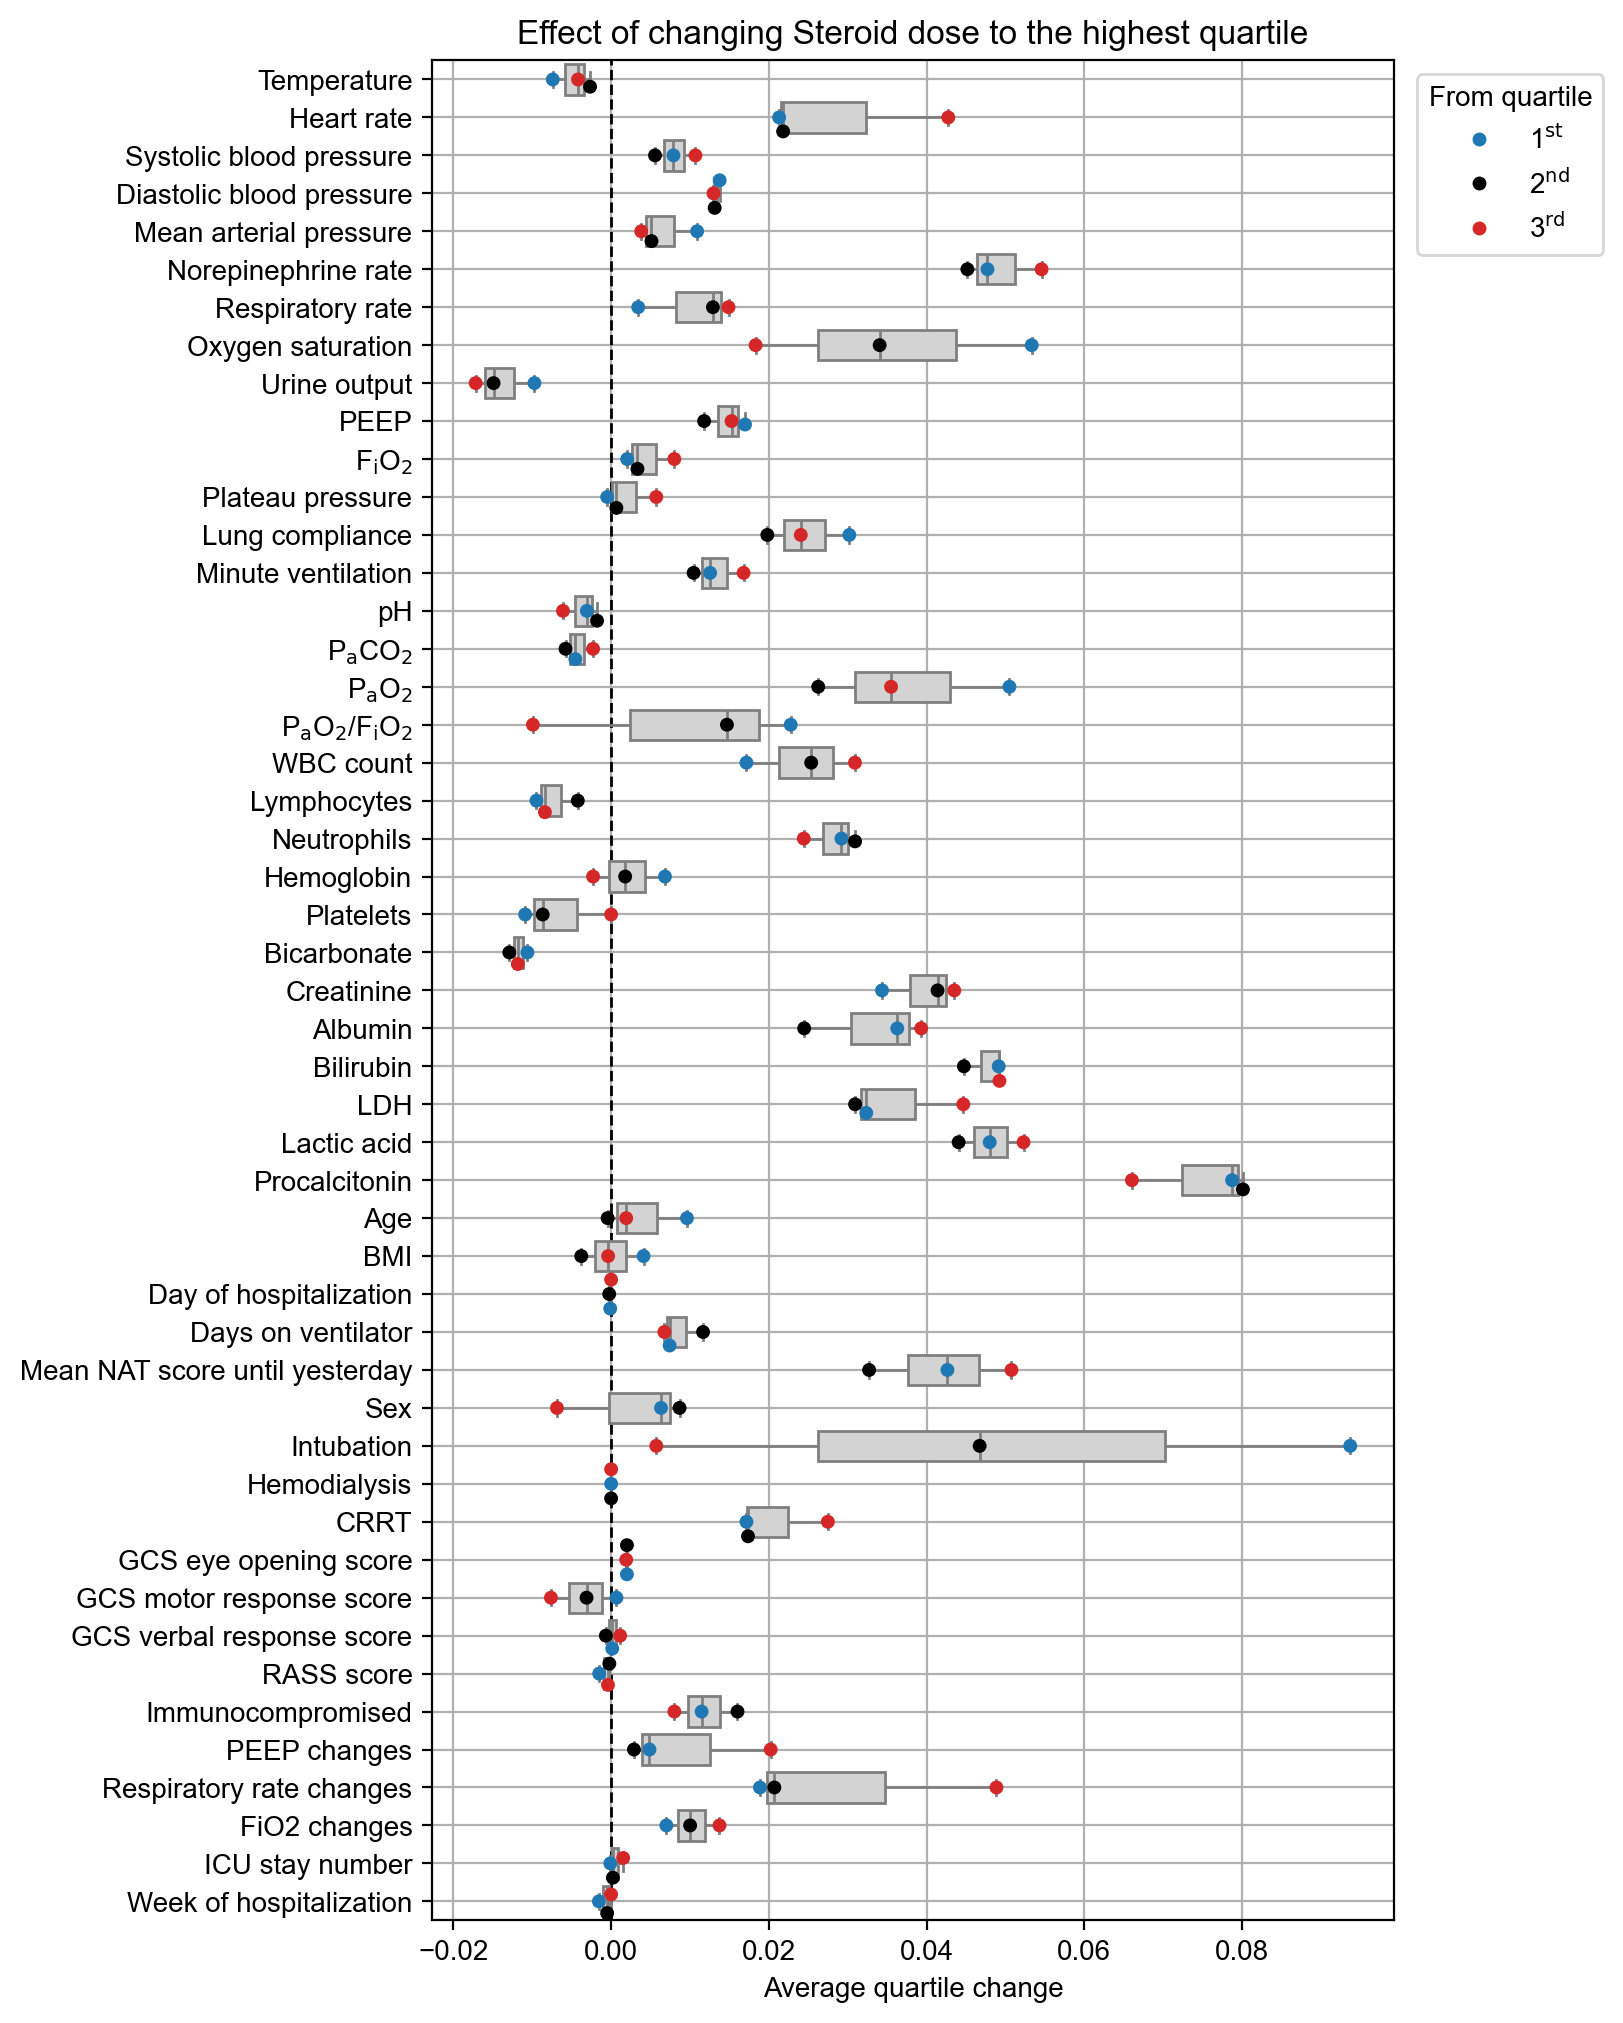

In [38]:
fig = plot_perturbation_effects(result_df, PRETTY_NAMES);
fig.savefig('00_plots/Fig_S2_perturb_steroids.pdf')